In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("googleplaystore.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [2]:
print(df.columns.tolist())

['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [4]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 483


In [5]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing Rating with median
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

# Remove remaining rows with missing values
df = df.dropna()

print("Dataset Shape after cleaning:", df.shape)
print("Missing Values:", df.isnull().sum().sum())

Dataset Shape after cleaning: (10346, 13)
Missing Values: 0


In [6]:
# Convert Reviews to numeric
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Convert Installs to numeric
df["Installs"] = (
    df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(float)
)

# Convert Price to numeric
df["Price"] = (
    df["Price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

# Check data types
print(df[["Reviews", "Installs", "Price"]].dtypes)

Reviews       int64
Installs    float64
Price       float64
dtype: object


In [7]:
# Display basic statistical information
print(df.describe())

            Rating       Reviews      Installs         Price
count  10346.00000  1.034600e+04  1.034600e+04  10346.000000
mean       4.20377  4.063338e+05  1.417266e+07      1.031561
std        0.48573  2.698179e+06  8.028090e+07     16.287252
min        1.00000  0.000000e+00  0.000000e+00      0.000000
25%        4.10000  3.200000e+01  1.000000e+03      0.000000
50%        4.30000  1.688500e+03  1.000000e+05      0.000000
75%        4.50000  4.659825e+04  1.000000e+06      0.000000
max        5.00000  7.815831e+07  1.000000e+09    400.000000


In [8]:
# Count apps in each category
category_counts = df["Category"].value_counts()

print(category_counts)

Category
FAMILY                 1939
GAME                   1121
TOOLS                   841
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         386
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     229
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  82
HOUSE_AND_HOME           80
EVENTS                   64
ART_AND_DESIGN           64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64


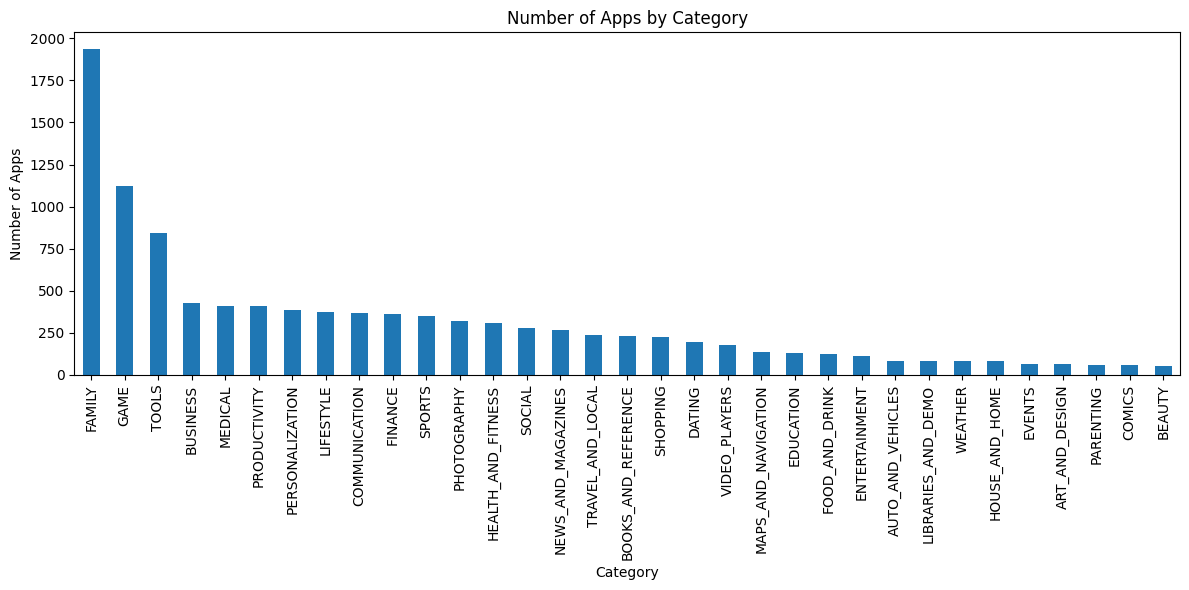

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

category_counts.plot(kind="bar")

plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("category_distribution.png")
plt.show()

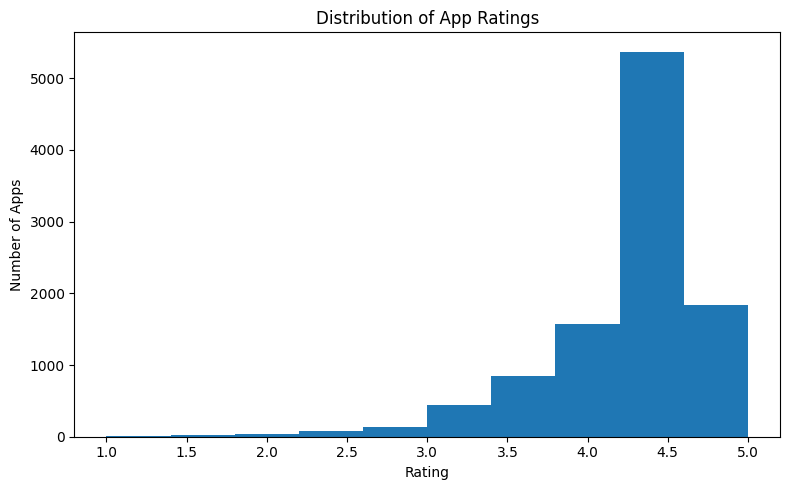

In [10]:
# Rating distribution

plt.figure(figsize=(8, 5))

plt.hist(df["Rating"], bins=10)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()

In [11]:
# Count Free and Paid apps
type_counts = df["Type"].value_counts()

print(type_counts)

Type
Free    9584
Paid     762
Name: count, dtype: int64


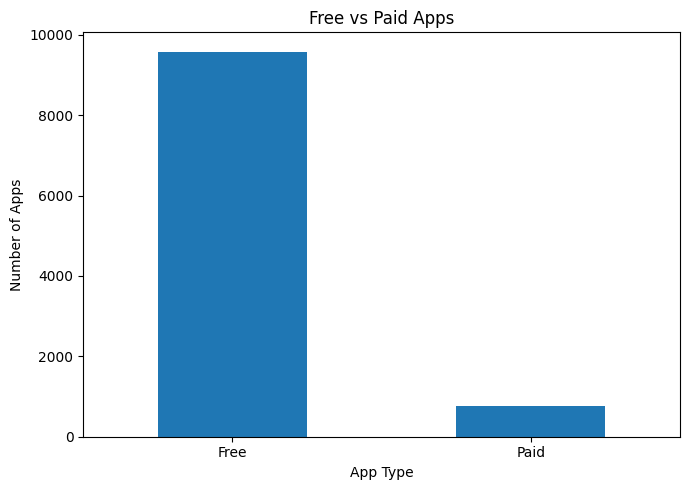

In [12]:
plt.figure(figsize=(7, 5))

type_counts.plot(kind="bar")

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("free_vs_paid.png")
plt.show()

In [13]:
# Top 10 most installed apps

top_installed = df.sort_values(
    by="Installs",
    ascending=False
).head(10)

print(top_installed[["App", "Category", "Installs", "Rating"]])

                            App            Category      Installs  Rating
336          WhatsApp Messenger       COMMUNICATION  1.000000e+09     4.4
2554                    Google+              SOCIAL  1.000000e+09     4.2
3127         Google Street View    TRAVEL_AND_LOCAL  1.000000e+09     4.2
3816                Google News  NEWS_AND_MAGAZINES  1.000000e+09     3.9
3223  Maps - Navigate & Explore    TRAVEL_AND_LOCAL  1.000000e+09     4.3
2545                  Instagram              SOCIAL  1.000000e+09     4.5
2544                   Facebook              SOCIAL  1.000000e+09     4.1
865           Google Play Games       ENTERTAINMENT  1.000000e+09     4.3
3234                     Google               TOOLS  1.000000e+09     4.4
3736                Google News  NEWS_AND_MAGAZINES  1.000000e+09     3.9


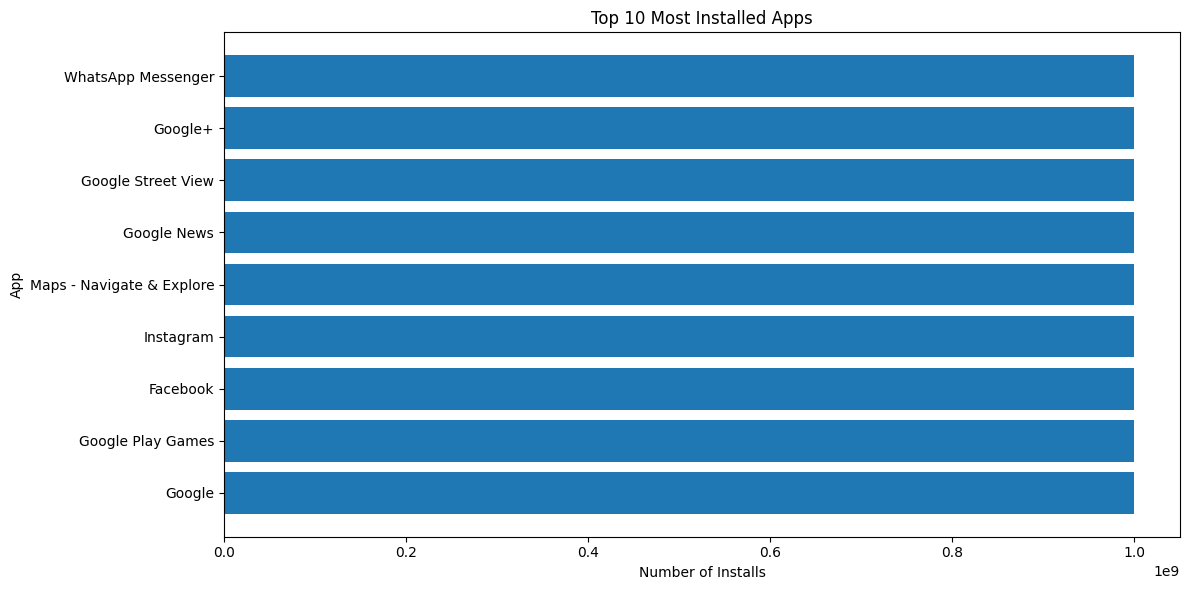

In [14]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_installed["App"],
    top_installed["Installs"]
)

plt.title("Top 10 Most Installed Apps")
plt.xlabel("Number of Installs")
plt.ylabel("App")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("top_10_installed_apps.png")
plt.show()

In [15]:
# Average rating by category

avg_rating_category = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_rating_category)

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.373437
BOOKS_AND_REFERENCE    4.336681
PERSONALIZATION        4.326425
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
SHOPPING               4.256250
WEATHER                4.248780
SPORTS                 4.239031
PRODUCTIVITY           4.219410
MEDICAL                4.212990
LIBRARIES_AND_DEMO     4.208333
AUTO_AND_VEHICLES      4.205882
FAMILY                 4.203713
PHOTOGRAPHY            4.189441
HOUSE_AND_HOME         4.185000
FOOD_AND_DRINK         4.183871
COMMUNICATION          4.175410
BUSINESS               4.175176
NEWS_AND_MAGAZINES     4.160985
COMICS                 4.160000
FINANCE                4.148056
ENTERTAINMENT          4.136036
LIFESTYLE              4.133244
TRAVEL_AND_LOCAL       4.121941
VIDEO_PLAYERS          4.084000
TOOLS                  4.079667

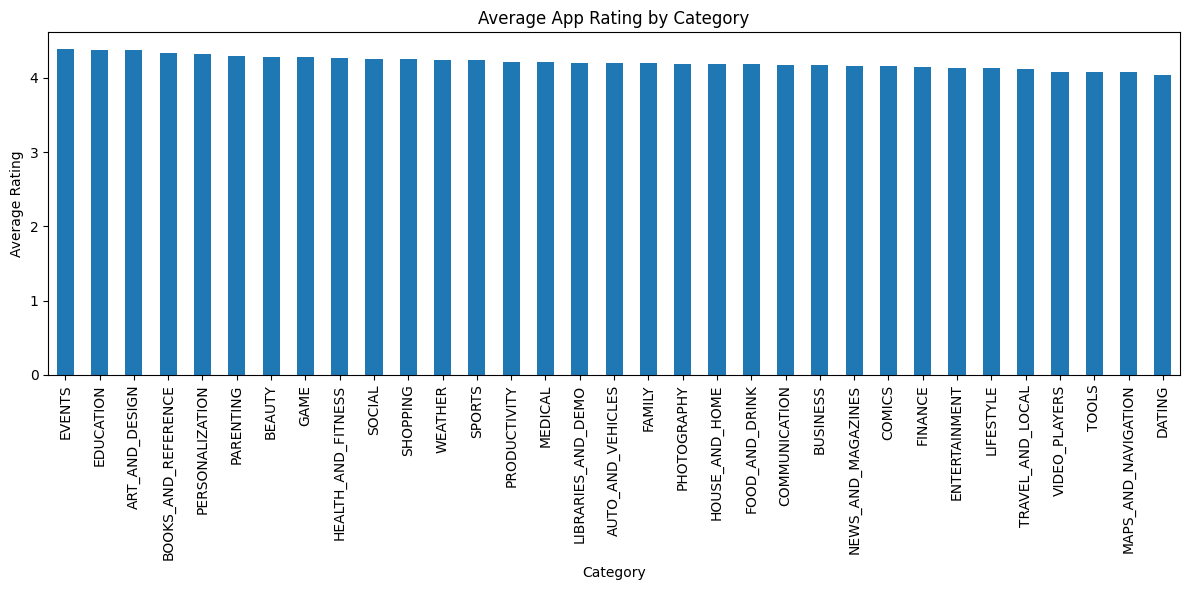

In [16]:
plt.figure(figsize=(12, 6))

avg_rating_category.plot(kind="bar")

plt.title("Average App Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("average_rating_by_category.png")
plt.show()

In [18]:
# Convert app size to numeric MB

def convert_size(size):
    if pd.isna(size):
        return None
    elif size == "Varies with device":
        return None
    elif str(size).endswith("M"):
        return float(str(size).replace("M", ""))
    elif str(size).endswith("k"):
        return float(str(size).replace("k", "")) / 1024
    else:
        return None

df["Size_MB"] = df["Size"].apply(convert_size)

print(df[["Size", "Size_MB"]].head(10))

   Size  Size_MB
0   19M     19.0
1   14M     14.0
2  8.7M      8.7
3   25M     25.0
4  2.8M      2.8
5  5.6M      5.6
6   19M     19.0
7   29M     29.0
8   33M     33.0
9  3.1M      3.1


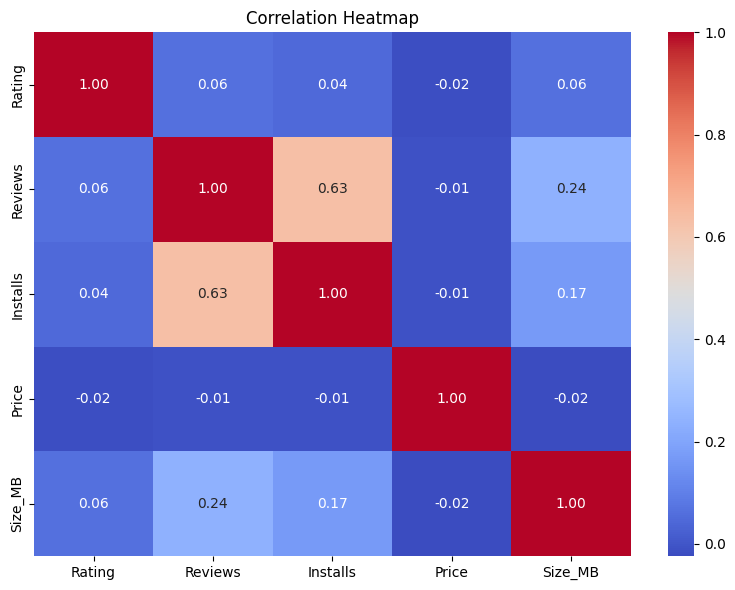

In [21]:
# Correlation heatmap

import seaborn as sns

numeric_cols = [
    "Rating",
    "Reviews",
    "Installs",
    "Price",
    "Size_MB"
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("correlation_heatmap.png")
plt.show()

In [22]:
# Select paid apps
paid_apps = df[df["Type"] == "Paid"]

print("Number of paid apps:", len(paid_apps))
print(paid_apps["Price"].describe())

Number of paid apps: 762
count    762.000000
mean      14.005945
std       58.516437
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


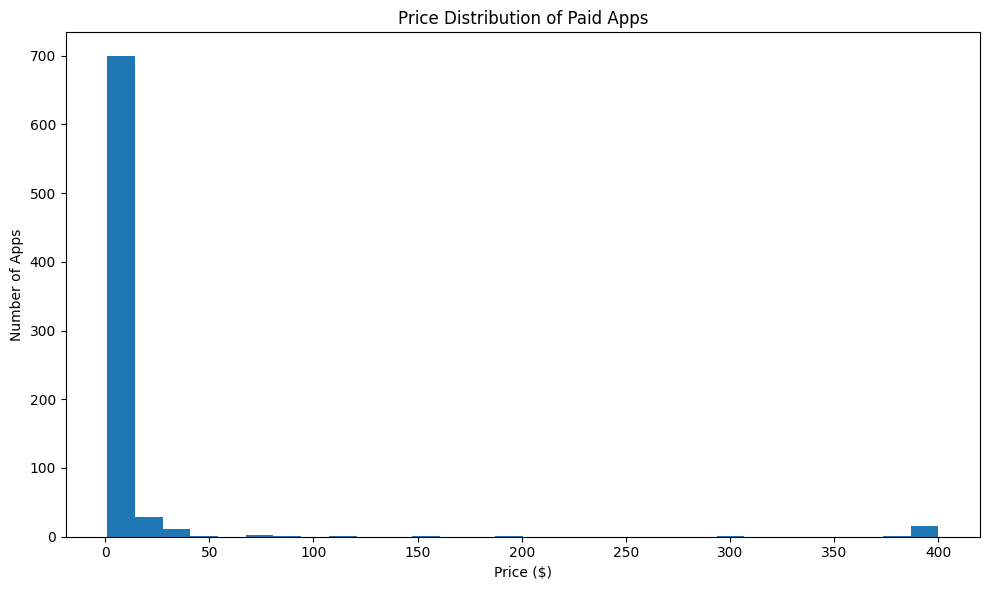

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(paid_apps["Price"], bins=30)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.savefig("paid_app_price_distribution.png")
plt.show()

In [24]:
# Count apps by content rating

content_rating_counts = df["Content Rating"].value_counts()

print(content_rating_counts)

Content Rating
Everyone           8372
Teen               1146
Mature 17+          447
Everyone 10+        376
Adults only 18+       3
Unrated               2
Name: count, dtype: int64


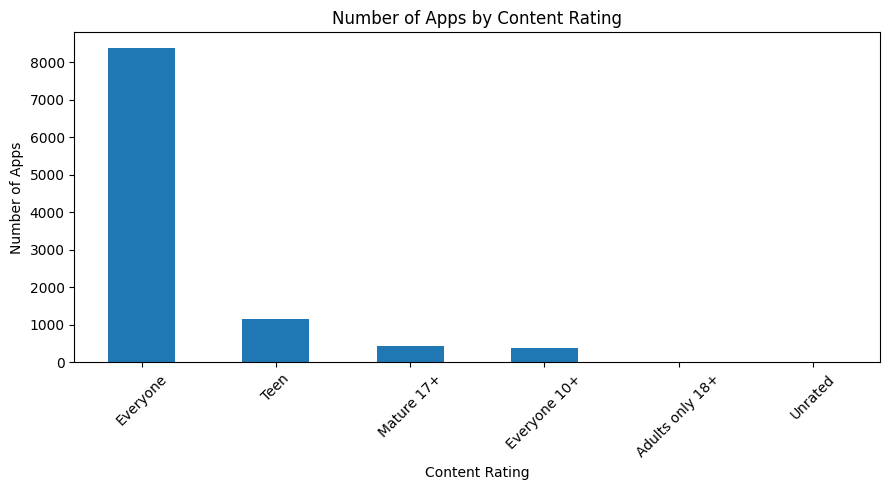

In [25]:
plt.figure(figsize=(9, 5))

content_rating_counts.plot(kind="bar")

plt.title("Number of Apps by Content Rating")
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("content_rating_distribution.png")
plt.show()

In [26]:
# Average installs by category

avg_installs_category = (
    df.groupby("Category")["Installs"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_installs_category)

Category
COMMUNICATION          6.598983e+07
SOCIAL                 4.469239e+07
VIDEO_PLAYERS          3.555430e+07
PRODUCTIVITY           3.062185e+07
PHOTOGRAPHY            3.019021e+07
GAME                   2.813918e+07
TRAVEL_AND_LOCAL       2.684341e+07
ENTERTAINMENT          2.212306e+07
NEWS_AND_MAGAZINES     2.042886e+07
TOOLS                  1.361745e+07
SHOPPING               1.148816e+07
BOOKS_AND_REFERENCE    8.368858e+06
PERSONALIZATION        5.374310e+06
MAPS_AND_NAVIGATION    5.286729e+06
WEATHER                5.196348e+06
FAMILY                 5.178769e+06
HEALTH_AND_FITNESS     4.447786e+06
SPORTS                 4.354913e+06
EDUCATION              4.107323e+06
FINANCE                2.139858e+06
FOOD_AND_DRINK         2.079829e+06
BUSINESS               2.022634e+06
ART_AND_DESIGN         1.942705e+06
HOUSE_AND_HOME         1.565156e+06
LIFESTYLE              1.433843e+06
DATING                 1.053756e+06
COMICS                 9.347692e+05
LIBRARIES_AND_DEMO 

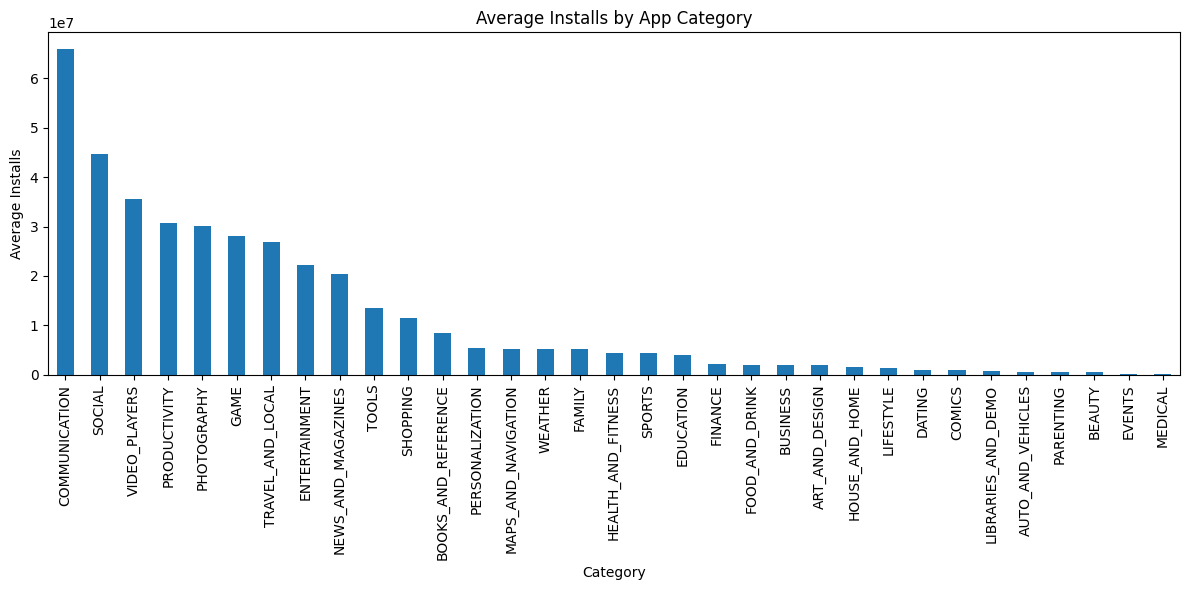

In [27]:
plt.figure(figsize=(12, 6))

avg_installs_category.plot(kind="bar")

plt.title("Average Installs by App Category")
plt.xlabel("Category")
plt.ylabel("Average Installs")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("average_installs_by_category.png")
plt.show()

In [28]:
# Count apps by genre

genre_counts = df["Genres"].value_counts().head(15)

print(genre_counts)

Genres
Tools               840
Entertainment       587
Education           526
Business            427
Medical             408
Productivity        407
Personalization     386
Lifestyle           372
Communication       366
Sports              364
Finance             360
Action              356
Photography         322
Health & Fitness    306
Social              280
Name: count, dtype: int64


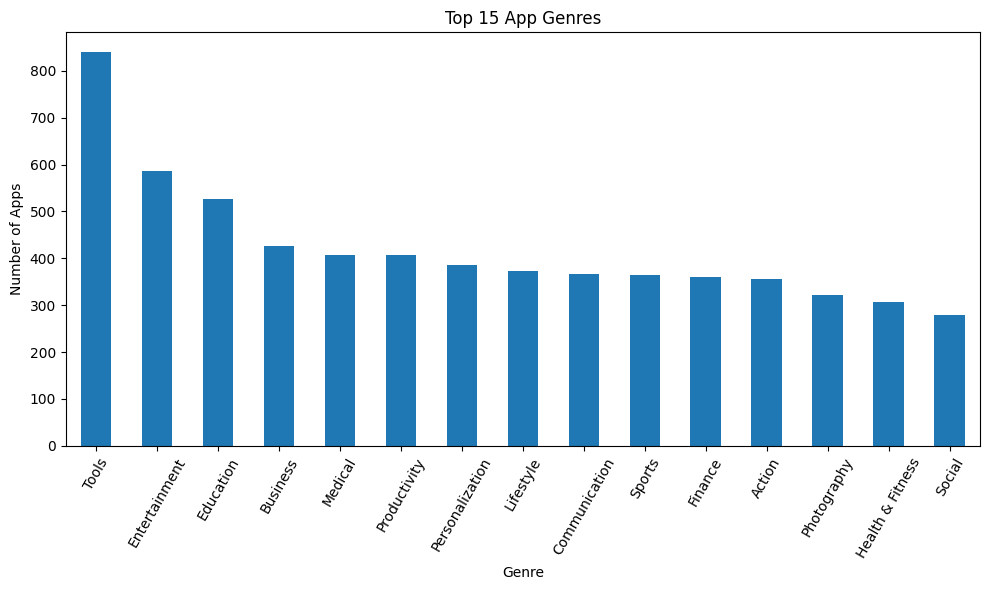

In [29]:
plt.figure(figsize=(10, 6))

genre_counts.plot(kind="bar")

plt.title("Top 15 App Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Apps")
plt.xticks(rotation=60)

plt.tight_layout()
plt.savefig("top_15_genres.png")
plt.show()

In [30]:
# Top 10 apps by reviews

top_reviewed = (
    df.sort_values("Reviews", ascending=False)
      .head(10)
)

print(top_reviewed[["App", "Category", "Reviews", "Rating"]])

                                           App       Category   Reviews  \
2544                                  Facebook         SOCIAL  78158306   
3943                                  Facebook         SOCIAL  78128208   
336                         WhatsApp Messenger  COMMUNICATION  69119316   
3904                        WhatsApp Messenger  COMMUNICATION  69109672   
2604                                 Instagram         SOCIAL  66577446   
2545                                 Instagram         SOCIAL  66577313   
3909                                 Instagram         SOCIAL  66509917   
382   Messenger – Text and Video Chat for Free  COMMUNICATION  56646578   
335   Messenger – Text and Video Chat for Free  COMMUNICATION  56642847   
1879                            Clash of Clans           GAME  44893888   

      Rating  
2544     4.1  
3943     4.1  
336      4.4  
3904     4.4  
2604     4.5  
2545     4.5  
3909     4.5  
382      4.0  
335      4.0  
1879     4.6  


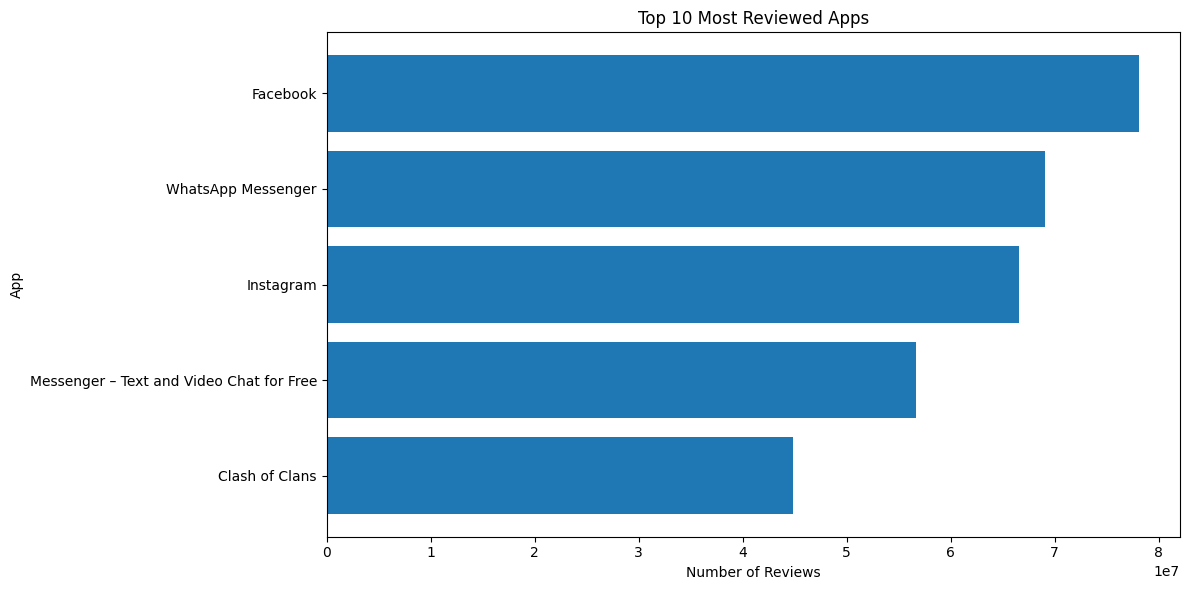

In [31]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_reviewed["App"],
    top_reviewed["Reviews"]
)

plt.title("Top 10 Most Reviewed Apps")
plt.xlabel("Number of Reviews")
plt.ylabel("App")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("most_reviewed_apps.png")
plt.show()

In [32]:
# Convert Last Updated to datetime

df["Last Updated"] = pd.to_datetime(
    df["Last Updated"],
    errors="coerce"
)

# Extract year
df["Updated Year"] = df["Last Updated"].dt.year

print(df["Updated Year"].value_counts().sort_index())

Updated Year
2010       1
2011      15
2012      26
2013     107
2014     204
2015     454
2016     787
2017    1823
2018    6929
Name: count, dtype: int64


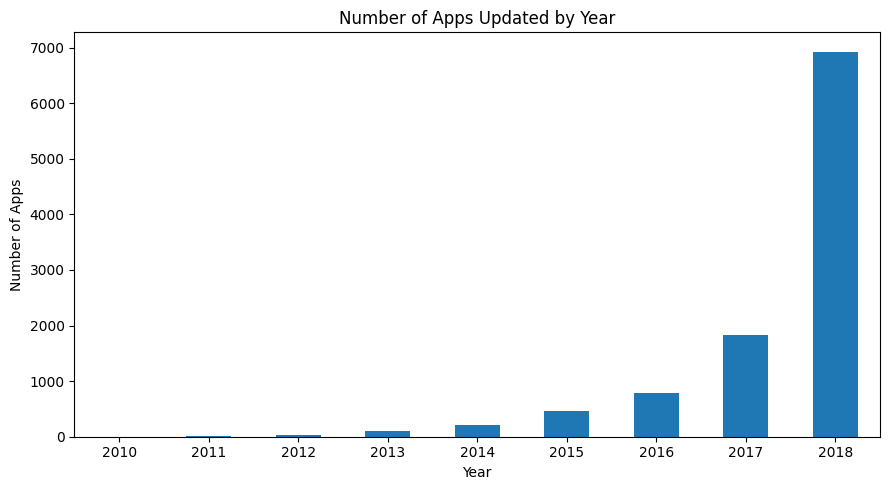

In [33]:
# Number of apps updated each year

yearly_updates = df["Updated Year"].value_counts().sort_index()

plt.figure(figsize=(9, 5))

yearly_updates.plot(kind="bar")

plt.title("Number of Apps Updated by Year")
plt.xlabel("Year")
plt.ylabel("Number of Apps")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("apps_updated_by_year.png")
plt.show()

In [34]:
# Top 10 highly rated apps with at least 1,000 reviews

top_rated = (
    df[df["Reviews"] >= 1000]
    .sort_values("Rating", ascending=False)
    .head(10)
)

print(top_rated[["App", "Category", "Rating", "Reviews"]])

                                                  App             Category  \
1833                               The Room: Old Sins                 GAME   
10527                                  FK Željezničar               SPORTS   
1258         Lose Belly Fat in 30 Days - Flat Stomach   HEALTH_AND_FITNESS   
177          eBoox new: Reader for fb2 epub zip books  BOOKS_AND_REFERENCE   
1260                Six Pack in 30 Days - Abs Workout   HEALTH_AND_FITNESS   
6690                                         Br Shafi               FAMILY   
79                            Tickets + PDA 2018 Exam    AUTO_AND_VEHICLES   
99                     ipsy: Makeup, Beauty, and Tips               BEAUTY   
712    Learn Japanese, Korean, Chinese Offline & Free            EDUCATION   
64              DMV Permit Practice Test 2018 Edition    AUTO_AND_VEHICLES   

       Rating  Reviews  
1833      4.9    21119  
10527     4.9     1420  
1258      4.9    38098  
177       4.9     2739  
1260      4.9   

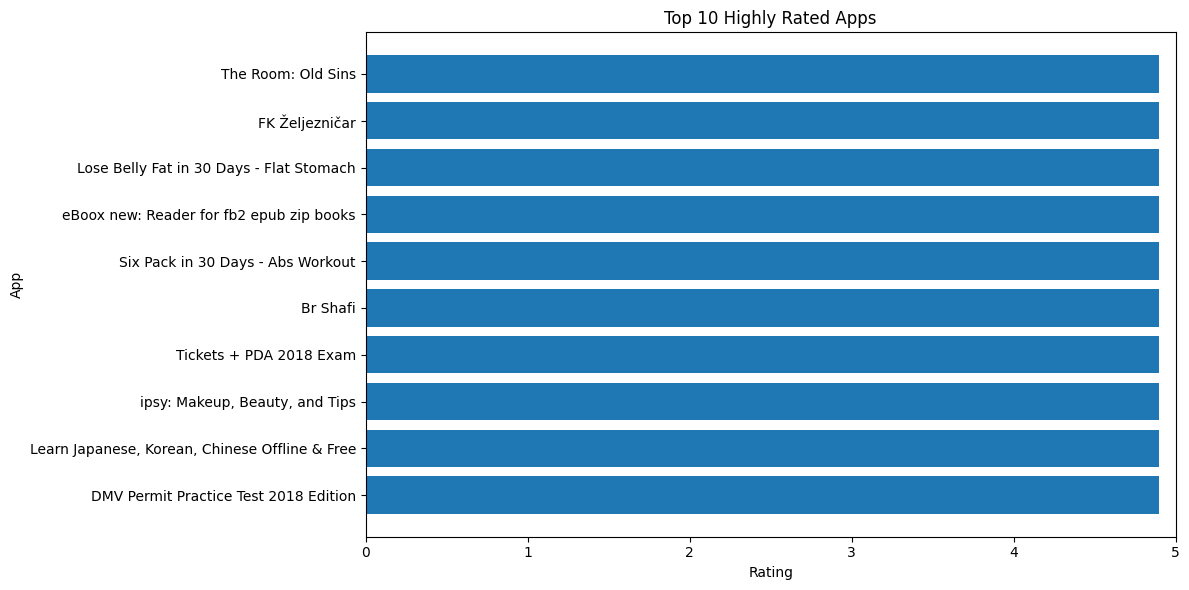

In [35]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_rated["App"],
    top_rated["Rating"]
)

plt.title("Top 10 Highly Rated Apps")
plt.xlabel("Rating")
plt.ylabel("App")

plt.xlim(0, 5)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("top_10_rated_apps.png")
plt.show()

In [36]:
# Count apps by required Android version

android_version_counts = df["Android Ver"].value_counts().head(15)

print(android_version_counts)

Android Ver
4.1 and up            2379
4.0.3 and up          1451
4.0 and up            1335
Varies with device    1220
4.4 and up             894
2.3 and up             642
5.0 and up             546
4.2 and up             386
2.3.3 and up           279
2.2 and up             239
3.0 and up             236
4.3 and up             235
2.1 and up             133
1.6 and up             115
6.0 and up              58
Name: count, dtype: int64


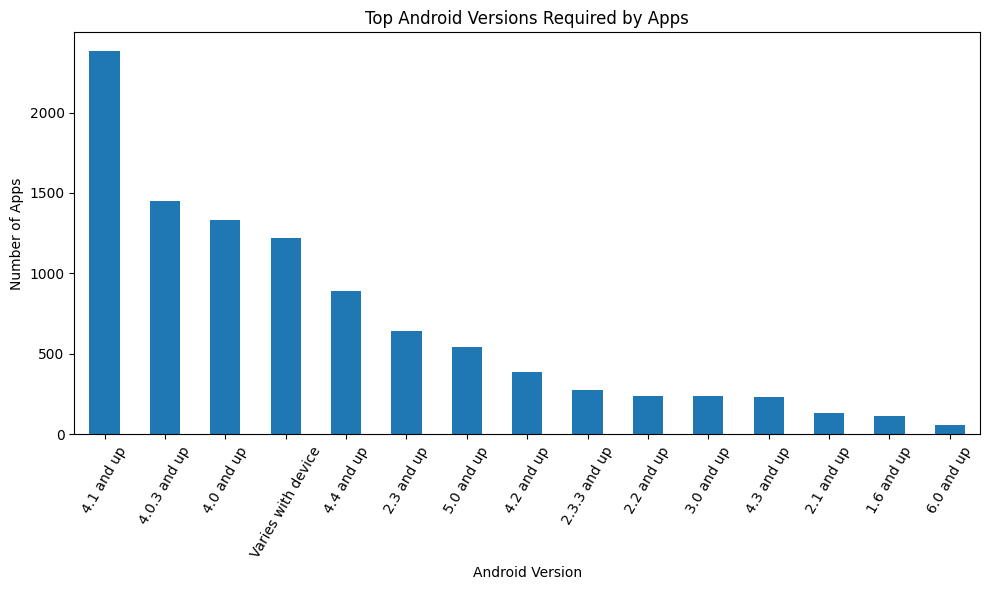

In [37]:
plt.figure(figsize=(10, 6))

android_version_counts.plot(kind="bar")

plt.title("Top Android Versions Required by Apps")
plt.xlabel("Android Version")
plt.ylabel("Number of Apps")
plt.xticks(rotation=60)

plt.tight_layout()
plt.savefig("android_version_distribution.png")
plt.show()

In [38]:
# Average rating for each category

category_rating = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print(category_rating)

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.373437
BOOKS_AND_REFERENCE    4.336681
PERSONALIZATION        4.326425
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
SHOPPING               4.256250
WEATHER                4.248780
SPORTS                 4.239031
PRODUCTIVITY           4.219410
MEDICAL                4.212990
LIBRARIES_AND_DEMO     4.208333
AUTO_AND_VEHICLES      4.205882
FAMILY                 4.203713
PHOTOGRAPHY            4.189441
HOUSE_AND_HOME         4.185000
FOOD_AND_DRINK         4.183871
COMMUNICATION          4.175410
BUSINESS               4.175176
NEWS_AND_MAGAZINES     4.160985
COMICS                 4.160000
FINANCE                4.148056
ENTERTAINMENT          4.136036
LIFESTYLE              4.133244
TRAVEL_AND_LOCAL       4.121941
VIDEO_PLAYERS          4.084000
TOOLS                  4.079667

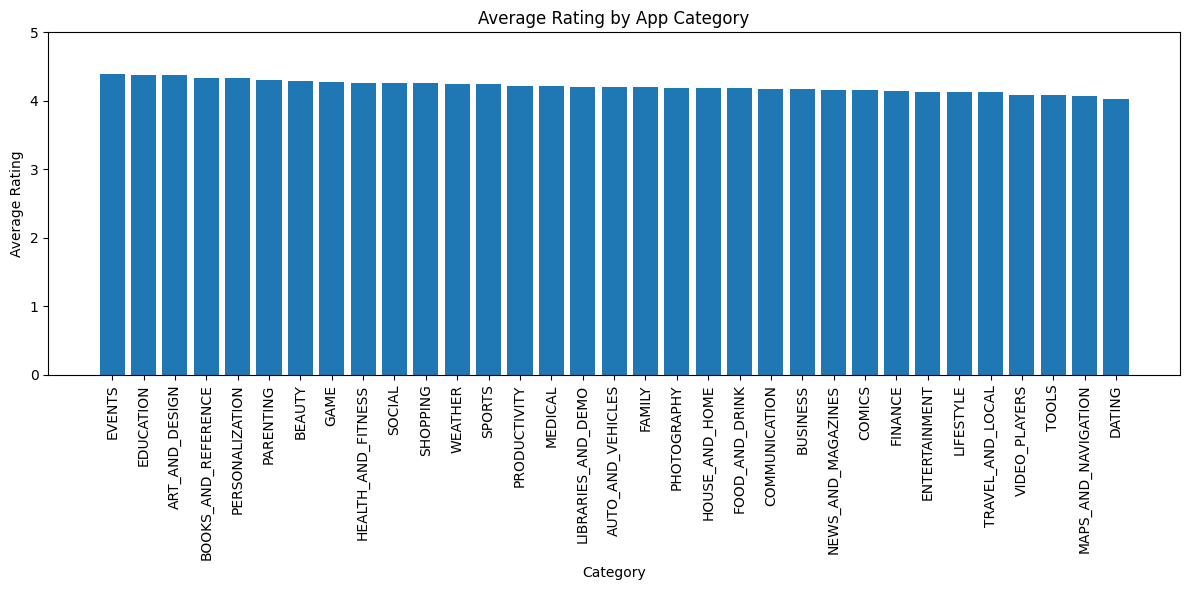

In [39]:
plt.figure(figsize=(12, 6))

plt.bar(
    category_rating.index,
    category_rating.values
)

plt.title("Average Rating by App Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=90)
plt.ylim(0, 5)

plt.tight_layout()
plt.savefig("category_vs_rating.png")
plt.show()

In [40]:
# Final dataset check

print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns.tolist())

Final Dataset Shape: (10346, 15)

Missing Values:
App                  0
Category             0
Rating               0
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
Size_MB           1525
Updated Year         0
dtype: int64

Columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Size_MB', 'Updated Year']


In [41]:
print(df[[
    "Rating",
    "Reviews",
    "Installs",
    "Price",
    "Size_MB"
]].describe())

            Rating       Reviews      Installs         Price      Size_MB
count  10346.00000  1.034600e+04  1.034600e+04  10346.000000  8821.000000
mean       4.20377  4.063338e+05  1.417266e+07      1.031561    21.306240
std        0.48573  2.698179e+06  8.028090e+07     16.287252    22.545826
min        1.00000  0.000000e+00  0.000000e+00      0.000000     0.008301
25%        4.10000  3.200000e+01  1.000000e+03      0.000000     4.700000
50%        4.30000  1.688500e+03  1.000000e+05      0.000000    13.000000
75%        4.50000  4.659825e+04  1.000000e+06      0.000000    29.000000
max        5.00000  7.815831e+07  1.000000e+09    400.000000   100.000000


In [42]:
# Save cleaned dataset

df.to_csv("GooglePlayStore_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [43]:
# Final project insights

print("Total Apps:", df["App"].nunique())

print("Average Rating:", round(df["Rating"].mean(), 2))

print("Most Common Category:", df["Category"].mode()[0])

print("Most Common Content Rating:", df["Content Rating"].mode()[0])

print("Free Apps:", (df["Type"] == "Free").sum())

print("Paid Apps:", (df["Type"] == "Paid").sum())

print("Most Installed App:",
      df.loc[df["Installs"].idxmax(), "App"])

print("Highest Install Count:",
      int(df["Installs"].max()))

print("Most Reviewed App:",
      df.loc[df["Reviews"].idxmax(), "App"])

print("Highest Review Count:",
      int(df["Reviews"].max()))

Total Apps: 9648
Average Rating: 4.2
Most Common Category: FAMILY
Most Common Content Rating: Everyone
Free Apps: 9584
Paid Apps: 762
Most Installed App: Google Play Books
Highest Install Count: 1000000000
Most Reviewed App: Facebook
Highest Review Count: 78158306


## Conclusion

The Google Play Store dataset was analyzed to understand app categories, ratings, installations, reviews, pricing, content ratings, genres, and Android version requirements.

The analysis showed that the majority of applications are free, while paid applications represent a smaller portion of the dataset. App ratings were generally high, with most applications receiving ratings above 4.0.

The project also identified the most installed and most reviewed applications, analyzed popular app categories and genres, and examined the relationship between app characteristics such as size, reviews, installs, price, and ratings.

Overall, the analysis provides useful insights into the Android app market and helps understand user preferences, app popularity, pricing patterns, and category-level trends.